In [304]:
import pandas as pd

In [305]:
df = pd.read_csv(r"C:\Users\sasir\Downloads\archive(1)\Walmart.csv")

In [306]:
df.columns

Index(['transaction_id', 'customer_id', 'product_id', 'product_name',
       'category', 'quantity_sold', 'unit_price', 'transaction_date',
       'store_id', 'store_location', 'inventory_level', 'reorder_point',
       'reorder_quantity', 'supplier_id', 'supplier_lead_time', 'customer_age',
       'customer_gender', 'customer_income', 'customer_loyalty_level',
       'payment_method', 'promotion_applied', 'promotion_type',
       'weather_conditions', 'holiday_indicator', 'weekday',
       'stockout_indicator', 'forecasted_demand', 'actual_demand'],
      dtype='object')

In [307]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 28 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   transaction_id          5000 non-null   int64  
 1   customer_id             5000 non-null   int64  
 2   product_id              5000 non-null   int64  
 3   product_name            5000 non-null   object 
 4   category                5000 non-null   object 
 5   quantity_sold           5000 non-null   int64  
 6   unit_price              5000 non-null   float64
 7   transaction_date        5000 non-null   object 
 8   store_id                5000 non-null   int64  
 9   store_location          5000 non-null   object 
 10  inventory_level         5000 non-null   int64  
 11  reorder_point           5000 non-null   int64  
 12  reorder_quantity        5000 non-null   int64  
 13  supplier_id             5000 non-null   int64  
 14  supplier_lead_time      5000 non-null   

## Preprocessing the Data

In [308]:
df.isnull().sum()

transaction_id               0
customer_id                  0
product_id                   0
product_name                 0
category                     0
quantity_sold                0
unit_price                   0
transaction_date             0
store_id                     0
store_location               0
inventory_level              0
reorder_point                0
reorder_quantity             0
supplier_id                  0
supplier_lead_time           0
customer_age                 0
customer_gender              0
customer_income              0
customer_loyalty_level       0
payment_method               0
promotion_applied            0
promotion_type            3407
weather_conditions           0
holiday_indicator            0
weekday                      0
stockout_indicator           0
forecasted_demand            0
actual_demand                0
dtype: int64

In [309]:
df['promotion_type']

0                       NaN
1       Percentage Discount
2                       NaN
3       Percentage Discount
4                       NaN
               ...         
4995                    NaN
4996                    NaN
4997                    NaN
4998                    NaN
4999                   BOGO
Name: promotion_type, Length: 5000, dtype: object

In [310]:
df['promotion_type'] = df['promotion_type'].fillna(0)

In [311]:
df.promotion_type

0                         0
1       Percentage Discount
2                         0
3       Percentage Discount
4                         0
               ...         
4995                      0
4996                      0
4997                      0
4998                      0
4999                   BOGO
Name: promotion_type, Length: 5000, dtype: object

In [312]:
df.isnull().sum()

transaction_id            0
customer_id               0
product_id                0
product_name              0
category                  0
quantity_sold             0
unit_price                0
transaction_date          0
store_id                  0
store_location            0
inventory_level           0
reorder_point             0
reorder_quantity          0
supplier_id               0
supplier_lead_time        0
customer_age              0
customer_gender           0
customer_income           0
customer_loyalty_level    0
payment_method            0
promotion_applied         0
promotion_type            0
weather_conditions        0
holiday_indicator         0
weekday                   0
stockout_indicator        0
forecasted_demand         0
actual_demand             0
dtype: int64

In [313]:
df['transaction_date'] 

0       3/31/2024 21:46
1       7/28/2024 12:45
2        6/10/2024 4:55
3        8/15/2024 1:03
4        9/13/2024 0:45
             ...       
4995      7/8/2024 6:13
4996     2/7/2024 11:30
4997     8/20/2024 0:38
4998    8/26/2024 11:05
4999      2/9/2024 1:27
Name: transaction_date, Length: 5000, dtype: object

In [314]:
df['transaction_date'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 5000 entries, 0 to 4999
Series name: transaction_date
Non-Null Count  Dtype 
--------------  ----- 
5000 non-null   object
dtypes: object(1)
memory usage: 39.2+ KB


In [315]:
print(df['transaction_date'].astype(str).str.len().value_counts())

transaction_date
14    2343
15    1984
13     673
Name: count, dtype: int64


In [316]:
df['transaction_date'] = pd.to_datetime(df['transaction_date'], format='%m/%d/%Y %H:%M')

In [317]:
df['transaction_date']

0      2024-03-31 21:46:00
1      2024-07-28 12:45:00
2      2024-06-10 04:55:00
3      2024-08-15 01:03:00
4      2024-09-13 00:45:00
               ...        
4995   2024-07-08 06:13:00
4996   2024-02-07 11:30:00
4997   2024-08-20 00:38:00
4998   2024-08-26 11:05:00
4999   2024-02-09 01:27:00
Name: transaction_date, Length: 5000, dtype: datetime64[ns]

In [318]:
df['transaction_date'] = df['transaction_date'].dt.normalize()

print(df['transaction_date'].head())

0   2024-03-31
1   2024-07-28
2   2024-06-10
3   2024-08-15
4   2024-09-13
Name: transaction_date, dtype: datetime64[ns]


In [319]:
df['unit_price'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 5000 entries, 0 to 4999
Series name: unit_price
Non-Null Count  Dtype  
--------------  -----  
5000 non-null   float64
dtypes: float64(1)
memory usage: 39.2 KB


In [320]:
df['Revenue'] = df['unit_price'] * df['quantity_sold']

In [321]:
df['Revenue']

0        565.38
1       7648.16
2       5511.00
3        911.55
4       1497.84
         ...   
4995     682.15
4996    4254.27
4997    1993.30
4998    3002.85
4999     710.03
Name: Revenue, Length: 5000, dtype: float64

## Agregating the Data 

In [322]:
global_daily_sales = df.groupby('transaction_date').agg(
    Total_volume = ('quantity_sold', 'sum'),
    Total_revenue = ('Revenue', 'sum'),
    Transaction_Count=('transaction_id', 'count'),
).reset_index()

#Sorting the dates chronologically
global_daily_sales = global_daily_sales.sort_values('transaction_date')

In [323]:
global_daily_sales

,transaction_date,Total_volume,Total_revenue,Transaction_Count
0,2024-01-01,72,89163.72,26
1,2024-01-02,24,20865.29,9
2,2024-01-03,59,62849.25,20
3,2024-01-04,67,61337.54,20
4,2024-01-05,66,66130.22,21
...,...,...,...,...
255,2024-09-12,64,72791.02,21
256,2024-09-13,69,56107.41,24
257,2024-09-14,60,62401.68,16
258,2024-09-15,60,60169.98,20


In [324]:
df

,transaction_id,customer_id,product_id,product_name,category,quantity_sold,unit_price,transaction_date,store_id,store_location,...,payment_method,promotion_applied,promotion_type,weather_conditions,holiday_indicator,weekday,stockout_indicator,forecasted_demand,actual_demand,Revenue
0,1,2824,843,Fridge,Electronics,3,188.46,2024-03-31,3,"Miami, FL",...,Credit Card,True,0,Stormy,False,Friday,True,172,179,565.38
1,2,1409,135,TV,Electronics,4,1912.04,2024-07-28,5,"Dallas, TX",...,Cash,True,Percentage Discount,Rainy,False,Monday,True,109,484,7648.16
2,3,5506,391,Fridge,Electronics,4,1377.75,2024-06-10,1,"Los Angeles, CA",...,Cash,False,0,Sunny,False,Tuesday,True,289,416,5511.00
3,4,5012,710,Smartphone,Electronics,5,182.31,2024-08-15,5,"Miami, FL",...,Cash,True,Percentage Discount,Sunny,True,Sunday,False,174,446,911.55
4,5,4657,116,Laptop,Electronics,3,499.28,2024-09-13,6,"Chicago, IL",...,Digital Wallet,False,0,Sunny,False,Thursday,True,287,469,1497.84
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4996,6898,852,Headphones,Appliances,1,682.15,2024-07-08,17,"New York, NY",...,Cash,False,0,Sunny,False,Wednesday,True,257,294,682.15
4996,4997,8412,886,Laptop,Appliances,3,1418.09,2024-02-07,16,"Los Angeles, CA",...,Digital Wallet,True,0,Sunny,True,Sunday,True,388,397,4254.27
4997,4998,8331,934,Fridge,Electronics,5,398.66,2024-08-20,16,"New York, NY",...,Digital Wallet,True,0,Cloudy,False,Thursday,True,314,204,1993.30
4998,4999,7505,439,Laptop,Appliances,3,1000.95,2024-08-26,16,"Miami, FL",...,Debit Card,True,0,Stormy,False,Tuesday,False,488,144,3002.85


In [325]:
store_daily_sales = df.groupby(['transaction_date', 'store_id']).agg(
    Total_Volume=('quantity_sold', 'sum'),
    Total_Revenue=('Revenue', 'sum')
).reset_index()

In [326]:
# complete range of dates from the start to the end of your dataset
all_dates = pd.date_range(start=global_daily_sales['transaction_date'].min(), 
                          end=global_daily_sales['transaction_date'].max(), 
                          freq='D')

# now Setting the date as the index, reindex to the complete date range, and fill missing with 0
global_daily_sales = global_daily_sales.set_index('transaction_date')
global_daily_sales = global_daily_sales.reindex(all_dates, fill_value=0)

# Rename the index back to transaction_date and reset it to a column
global_daily_sales.index.name = 'transaction_date'
global_daily_sales = global_daily_sales.reset_index()

## Visualizing aggregated data

In [327]:
import matplotlib.pyplot as plt
import seaborn as sns

# Extracting temporal features for grouping
global_daily_sales['Month'] = global_daily_sales['transaction_date'].dt.month
global_daily_sales['DayOfWeek'] = global_daily_sales['transaction_date'].dt.day_name()

# Ordering the days of the week for plotting
ordered_days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
global_daily_sales['DayOfWeek'] = pd.Categorical(global_daily_sales['DayOfWeek'], categories=ordered_days, ordered=True)

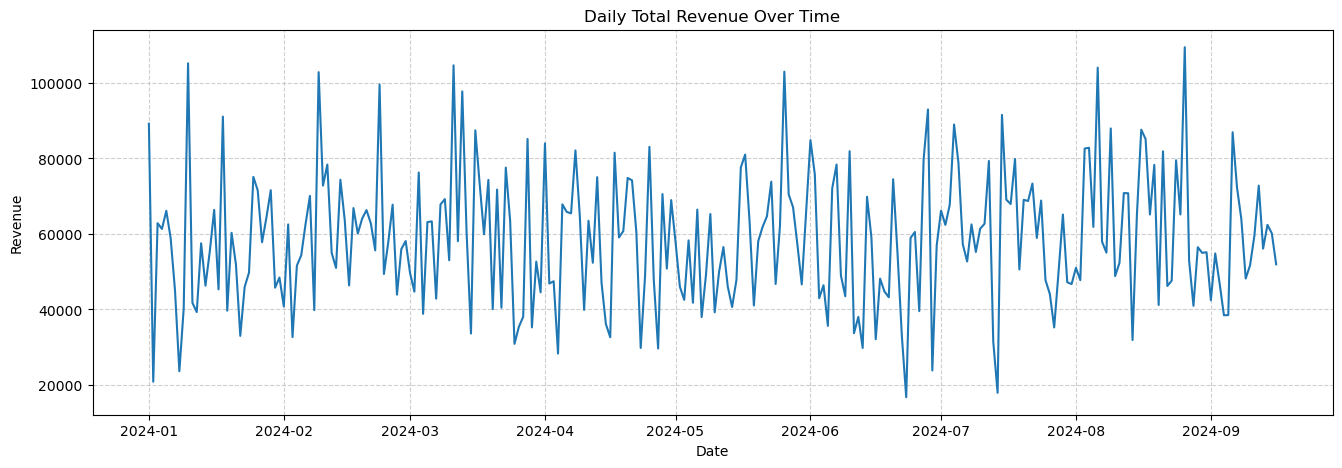

In [328]:
plt.figure(figsize=(16, 5))
sns.lineplot(data=global_daily_sales, x='transaction_date', y='Total_revenue', linewidth=1.5)
plt.title('Daily Total Revenue Over Time')
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### the data in the plot is highly turbulent due to high-frequency weekly seasonality. In retail, sales do not follow a smooth line; they violently zigzag because weekends or specific promotional days see massive revenue spikes, followed by sharp drop-offs during the mid-week slump.

## filtering out that day-to-day noise using a moving average to see if walmart is really growing over the 9 month period or it is shrinking 

In [329]:
# calculation the 7 day moving average 

global_daily_sales['Revenue_7D_ma'] = global_daily_sales['Total_revenue'].rolling(window=7).mean() 

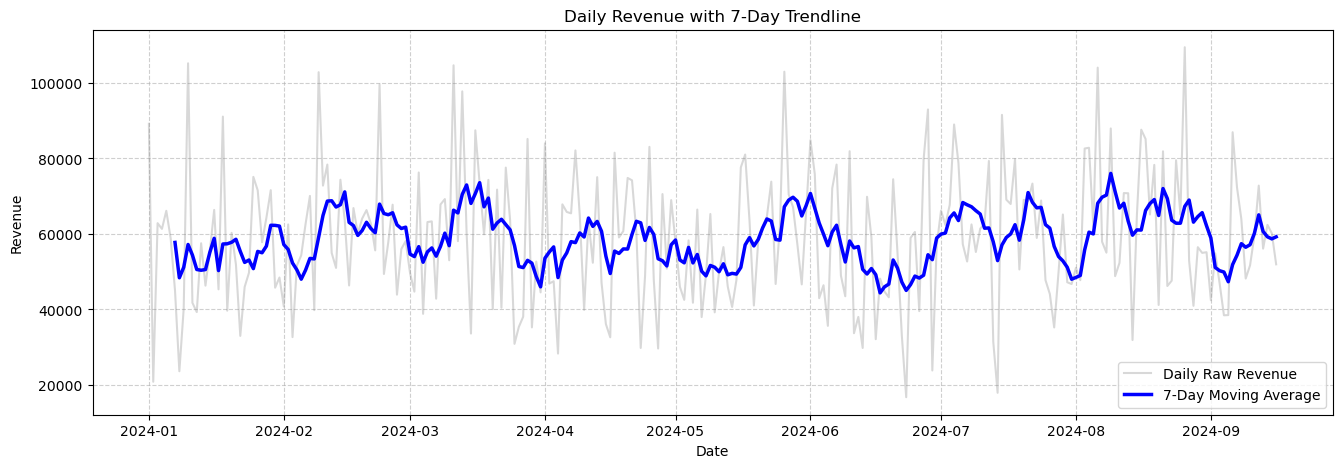

In [330]:
# raw data vs the smoothed trend
plt.figure(figsize=(16, 5))
sns.lineplot(data=global_daily_sales, x='transaction_date', y='Total_revenue', 
             color='gray', alpha=0.3, label='Daily Raw Revenue')
sns.lineplot(data=global_daily_sales, x='transaction_date', y='Revenue_7D_ma', 
             color='blue', linewidth=2.5, label='7-Day Moving Average')

plt.title('Daily Revenue with 7-Day Trendline')
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [331]:
global_daily_sales = global_daily_sales.sort_values('transaction_date').reset_index(drop=True)

## Feature Engineering 

In [332]:
# Extracting basic calendar features
global_daily_sales['DayOfWeek'] = global_daily_sales['transaction_date'].dt.dayofweek # 0=Mon, 6=Sun
global_daily_sales['Is_Weekend'] = global_daily_sales['DayOfWeek'].isin([5, 6]).astype(int)
global_daily_sales['Month'] = global_daily_sales['transaction_date'].dt.month
global_daily_sales['DayOfMonth'] = global_daily_sales['transaction_date'].dt.day

In [333]:
# What were the sales exactly 1 day ago? (Captures immediate momentum)
global_daily_sales['Revenue_Lag_1'] = global_daily_sales['Total_revenue'].shift(1)

# What were the sales exactly 7 days ago? (Captures the weekly cycle)
global_daily_sales['Revenue_Lag_7'] = global_daily_sales['Total_revenue'].shift(7)

# What were the sales 28 days ago? (Captures monthly recurring behavior)
global_daily_sales['Revenue_Lag_28'] = global_daily_sales['Total_revenue'].shift(28)

In [334]:
# The trend leading up to today
global_daily_sales['Rolling_Mean_7D'] = global_daily_sales['Total_revenue'].shift(1).rolling(window=7).mean()
global_daily_sales['Rolling_Std_7D'] = global_daily_sales['Total_revenue'].shift(1).rolling(window=7).std() 

In [335]:
global_daily_sales.isna().sum()

transaction_date      0
Total_volume          0
Total_revenue         0
Transaction_Count     0
Month                 0
DayOfWeek             0
Revenue_7D_ma         6
Is_Weekend            0
DayOfMonth            0
Revenue_Lag_1         1
Revenue_Lag_7         7
Revenue_Lag_28       28
Rolling_Mean_7D       7
Rolling_Std_7D        7
dtype: int64

In [336]:
# Dropping the initial rows that lack sufficient historical data
model_df = global_daily_sales.dropna().reset_index(drop=True)

In [337]:
global_daily_sales.columns

Index(['transaction_date', 'Total_volume', 'Total_revenue',
       'Transaction_Count', 'Month', 'DayOfWeek', 'Revenue_7D_ma',
       'Is_Weekend', 'DayOfMonth', 'Revenue_Lag_1', 'Revenue_Lag_7',
       'Revenue_Lag_28', 'Rolling_Mean_7D', 'Rolling_Std_7D'],
      dtype='object')

# Exploratory Data Analysis

C:\Users\sasir\AppData\Local\Temp\ipykernel_12796\464021157.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=global_daily_sales, x='Month', y='Total_revenue', palette='viridis')


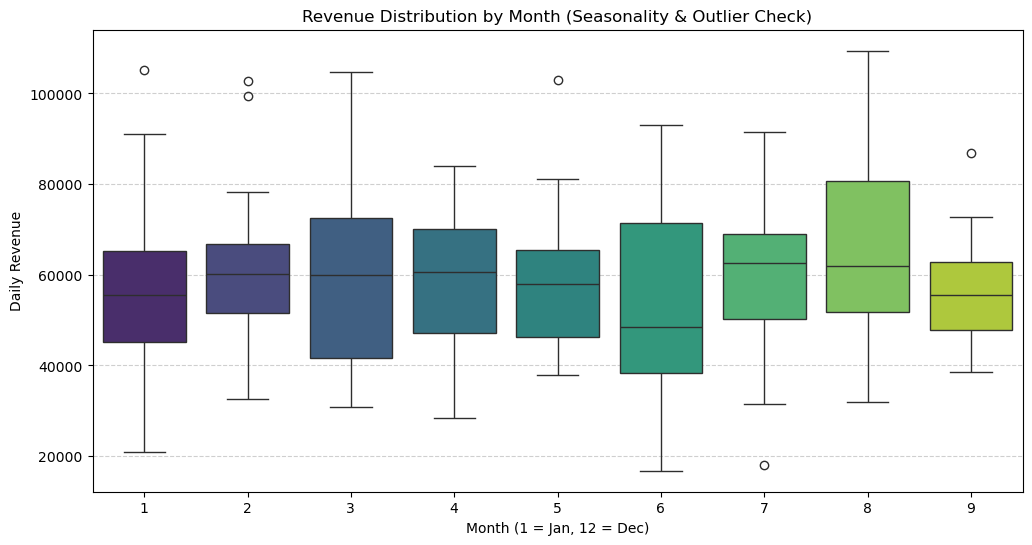

In [338]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=global_daily_sales, x='Month', y='Total_revenue', palette='viridis')
plt.title('Revenue Distribution by Month (Seasonality & Outlier Check)')
plt.xlabel('Month (1 = Jan, 12 = Dec)')
plt.ylabel('Daily Revenue')
plt.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.show()

In [339]:
#  Q1, Q3, and the IQR
Q1 = global_daily_sales['Total_revenue'].quantile(0.25)
Q3 = global_daily_sales['Total_revenue'].quantile(0.75)
IQR = Q3 - Q1

# upper and lower boundaries
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filtering the dataset to show only the statistical outliers
outliers = global_daily_sales[(global_daily_sales['Total_revenue'] < lower_bound) | 
                              (global_daily_sales['Total_revenue'] > upper_bound)]

# Sort them by revenue to inspect the biggest spikes
top_outliers = outliers[['transaction_date', 'Total_revenue', 'Month']].sort_values('Total_revenue', ascending=False)
print(top_outliers.head(15))

    transaction_date  Total_revenue  Month
238       2024-08-26      109432.61      8
9         2024-01-10      105179.48      1
70        2024-03-11      104647.48      3
218       2024-08-06      104023.53      8


C:\Users\sasir\AppData\Local\Temp\ipykernel_12796\383198493.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=global_daily_sales, x='DayOfWeek', y='Total_revenue', palette='coolwarm')


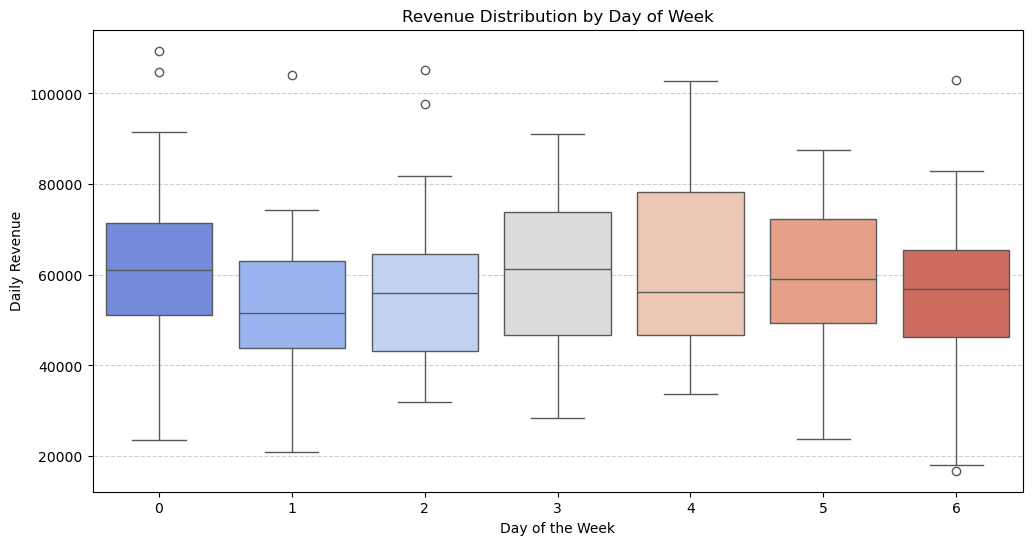

In [340]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=global_daily_sales, x='DayOfWeek', y='Total_revenue', palette='coolwarm')
plt.title('Revenue Distribution by Day of Week')
plt.xlabel('Day of the Week')
plt.ylabel('Daily Revenue')
plt.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.show()

In [341]:
global_daily_sales['Total_revenue'].describe()

count       260.000000
mean      58706.159423
std       17455.810875
min       16770.800000
25%       46345.167500
50%       58104.190000
75%       69107.007500
max      109432.610000
Name: Total_revenue, dtype: float64

In [342]:
global_daily_sales['Total_revenue'].median()

58104.19

## mean and median are almost close

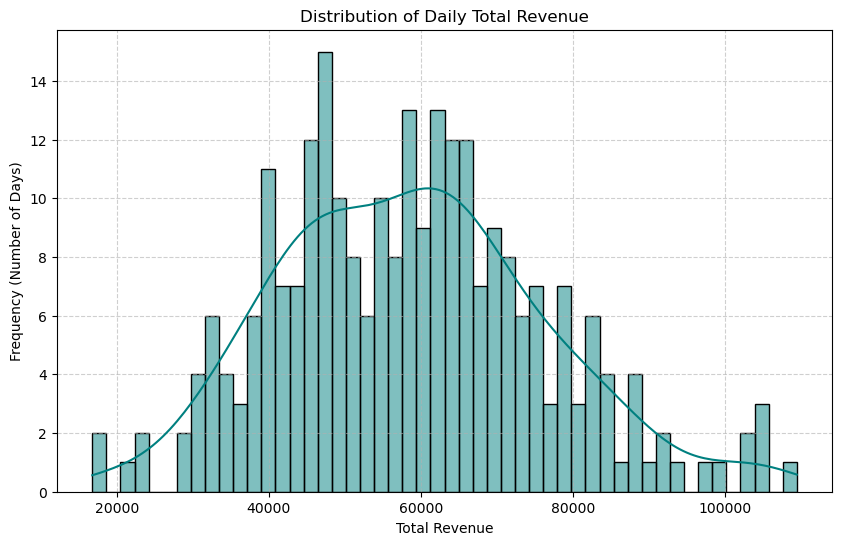

In [343]:
# 1. Histogram with KDE
plt.figure(figsize=(10, 6))
sns.histplot(global_daily_sales['Total_revenue'], bins=50, kde=True, color='teal')
plt.title('Distribution of Daily Total Revenue')
plt.xlabel('Total Revenue')
plt.ylabel('Frequency (Number of Days)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## The histogram shows a surprisingly symmetrical shape for retail data, with the bulk of daily revenue naturally clustering between roughly 40,000 and 70,000. However, because there is a slight right-sided tail reaching past 100,000, I am transforming the data.

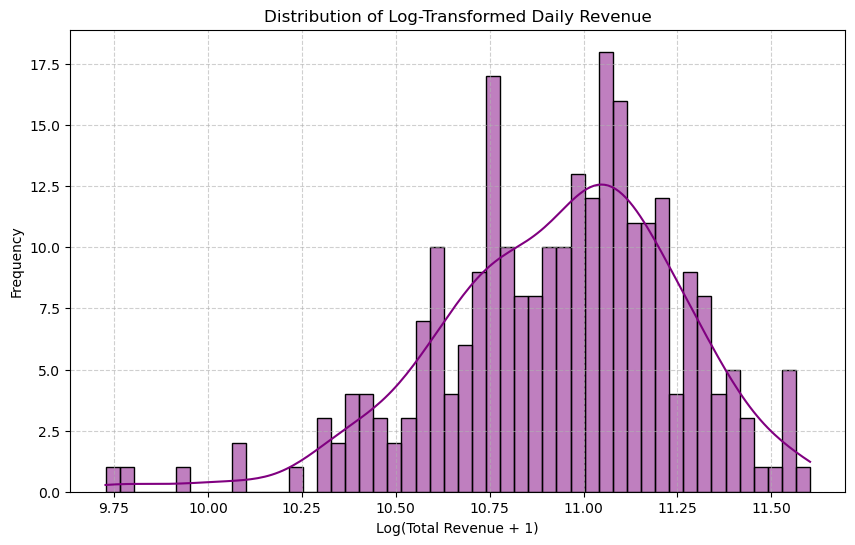

In [344]:
import numpy as np

# Applying the log1p transformation to the target variable
global_daily_sales['Log_Total_revenue'] = np.log1p(global_daily_sales['Total_revenue'])

# Plot the transformed distribution to verify the tail is pulled in
plt.figure(figsize=(10, 6))
sns.histplot(global_daily_sales['Log_Total_revenue'], bins=50, kde=True, color='purple')
plt.title('Distribution of Log-Transformed Daily Revenue')
plt.xlabel('Log(Total Revenue + 1)')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## well that didnt go well ;( , the lop p transformation created a left skew data and hence using this transformation doesnt make sense

### I am reverting to using the original raw data 

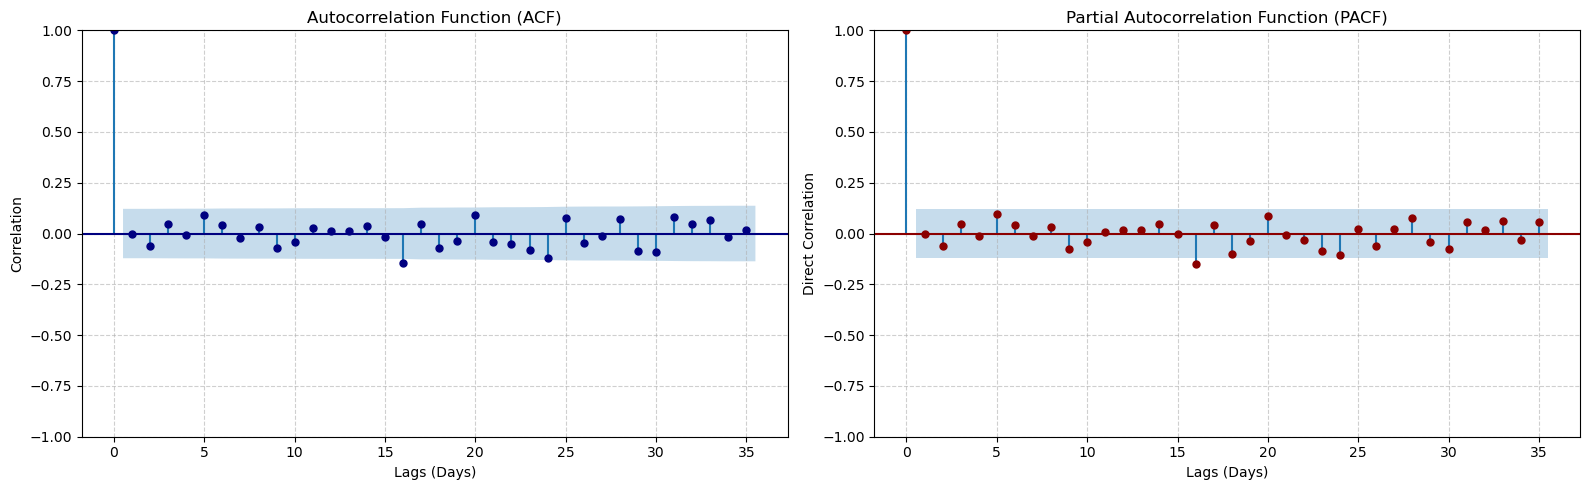

In [345]:
import statsmodels.api as sm

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ACF 
sm.graphics.tsa.plot_acf(global_daily_sales['Total_revenue'].dropna(), lags=35, ax=axes[0], color='navy')
axes[0].set_title('Autocorrelation Function (ACF)')
axes[0].set_xlabel('Lags (Days)')
axes[0].set_ylabel('Correlation')
axes[0].grid(True, linestyle='--', alpha=0.6)

# PACF 
sm.graphics.tsa.plot_pacf(global_daily_sales['Total_revenue'].dropna(), lags=35, ax=axes[1], color='darkred', method='ywm')
axes[1].set_title('Partial Autocorrelation Function (PACF)')
axes[1].set_xlabel('Lags (Days)')
axes[1].set_ylabel('Direct Correlation')
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### the ACF and the PACF are nearly flat lines in the ACF and PACF plots are delivering a very clear mathematical verdict: 
Past global sales are virtually useless for predicting future global sales in this dataset configuration, there is no statistically significant correlation between today's revenue and the revenue from 1, 7, or 14 days ago. At a global, aggregated level, your target variable is behaving largely like random white noise.

### Fitting a ARIMA model or SARIMA will predict will flatline and predict a straight average.

## There Checking same ACF and PACF on the Shop level data 

In [346]:
# 0 = Monday, 6 = Sunday. isin([5, 6]) flags Saturday and Sunday as 1.
store_daily_sales['Is_Weekend'] = store_daily_sales['transaction_date'].dt.dayofweek.isin([5, 6]).astype(int)

In [347]:
import pandas as pd

target_store = '5' 
single_store_data = df[df['store_id'] == target_store].copy()

# 2. Ensure your date column is a datetime object so the groupby aligns correctly
single_store_data['transaction_date'] = pd.to_datetime(single_store_data['transaction_date'])

# Map Holidays
daily_holidays = single_store_data.groupby('transaction_date')['holiday_indicator'].max()
store_daily_sales['Is_Holiday'] = store_daily_sales['transaction_date'].map(daily_holidays).replace({
    'True': 1, 'False': 0, True: 1, False: 0
}).fillna(0).astype(int)

# Map Promotions
daily_promos = single_store_data.groupby('transaction_date')['promotion_applied'].max()
store_daily_sales['promotion_applied'] = store_daily_sales['transaction_date'].map(daily_promos).replace({
    'True': 1, 'False': 0, True: 1, False: 0
}).fillna(0).astype(int)

print(store_daily_sales[['transaction_date', 'Is_Holiday', 'promotion_applied']].head(10))

  transaction_date  Is_Holiday  promotion_applied
0       2024-01-01           0                  0
1       2024-01-01           0                  0
2       2024-01-01           0                  0
3       2024-01-01           0                  0
4       2024-01-01           0                  0
5       2024-01-01           0                  0
6       2024-01-01           0                  0
7       2024-01-01           0                  0
8       2024-01-01           0                  0
9       2024-01-01           0                  0


In [348]:

# 1. Build Is_Holiday (Your correct code)
daily_holidays = single_store_data.groupby('transaction_date')['holiday_indicator'].max()
store_daily_sales['Is_Holiday'] = store_daily_sales['transaction_date'].map(daily_holidays).replace({
    'True': 1, 'False': 0, True: 1, False: 0
}).fillna(0).astype(int)

# 2. Build promotion_applied (Targeting the correct column)
# ** CRITICAL: Replace 'promotion_indicator' with the actual column name in your raw data **
daily_promos = single_store_data.groupby('transaction_date')['promotion_applied'].max()
store_daily_sales['promotion_applied'] = store_daily_sales['transaction_date'].map(daily_promos).replace({
    'True': 1, 'False': 0, True: 1, False: 0
}).fillna(0).astype(int)

# 3. Verify the features are no longer identical clones
print(store_daily_sales[['transaction_date', 'Is_Holiday', 'promotion_applied']].head(10))

  transaction_date  Is_Holiday  promotion_applied
0       2024-01-01           0                  0
1       2024-01-01           0                  0
2       2024-01-01           0                  0
3       2024-01-01           0                  0
4       2024-01-01           0                  0
5       2024-01-01           0                  0
6       2024-01-01           0                  0
7       2024-01-01           0                  0
8       2024-01-01           0                  0
9       2024-01-01           0                  0


In [349]:
# Map Holidays
daily_holidays = single_store_data.groupby('transaction_date')['holiday_indicator'].max()
store_daily_sales['Is_Holiday'] = store_daily_sales['transaction_date'].map(daily_holidays).isin(
    [True, 'True', 'true', 1, '1']
).astype(int)

# Map Promotions
daily_promos = single_store_data.groupby('transaction_date')['promotion_applied'].max()
store_daily_sales['promotion_applied'] = store_daily_sales['transaction_date'].map(daily_promos).isin(
    [True, 'True', 'true', 1, '1']
).astype(int)

print(store_daily_sales[['transaction_date', 'Is_Holiday', 'promotion_applied']].head(10))

  transaction_date  Is_Holiday  promotion_applied
0       2024-01-01           0                  0
1       2024-01-01           0                  0
2       2024-01-01           0                  0
3       2024-01-01           0                  0
4       2024-01-01           0                  0
5       2024-01-01           0                  0
6       2024-01-01           0                  0
7       2024-01-01           0                  0
8       2024-01-01           0                  0
9       2024-01-01           0                  0


In [350]:
store_daily_sales.columns

Index(['transaction_date', 'store_id', 'Total_Volume', 'Total_Revenue',
       'Is_Weekend', 'Is_Holiday', 'promotion_applied'],
      dtype='object')

In [351]:
store_daily_sales['promotion_applied'] = single_store_data.groupby('transaction_date')['promotion_applied'].max()


store_daily_sales['promotion_applied'] = store_daily_sales['transaction_date'].map(daily_holidays)

store_daily_sales['promotion_applied'] = store_daily_sales['Is_Holiday'].replace({
    'True': 1, 'False': 0, 
    True: 1, False: 0
}).fillna(0).astype(int)

print(store_daily_sales[['transaction_date', 'Is_Holiday','promotion_applied']].head())

  transaction_date  Is_Holiday  promotion_applied
0       2024-01-01           0                  0
1       2024-01-01           0                  0
2       2024-01-01           0                  0
3       2024-01-01           0                  0
4       2024-01-01           0                  0


In [352]:
top_store_id = df['store_id'].value_counts().idxmax()
print(f'testing granularity level data of store: {top_store_id}')
single_store_data = df[df['store_id'] == top_store_id]

store_daily_sales = single_store_data.groupby('transaction_date').agg(
    total_revenue = ('Revenue','sum')
).reset_index() 

display(store_daily_sales.head())


testing granularity level data of store: 5


,transaction_date,total_revenue
0,2024-01-01,1072.17
1,2024-01-02,974.04
2,2024-01-04,7257.50
3,2024-01-06,1058.06
4,2024-01-08,3969.21


In [353]:
store_daily_sales.columns

Index(['transaction_date', 'total_revenue'], dtype='object')

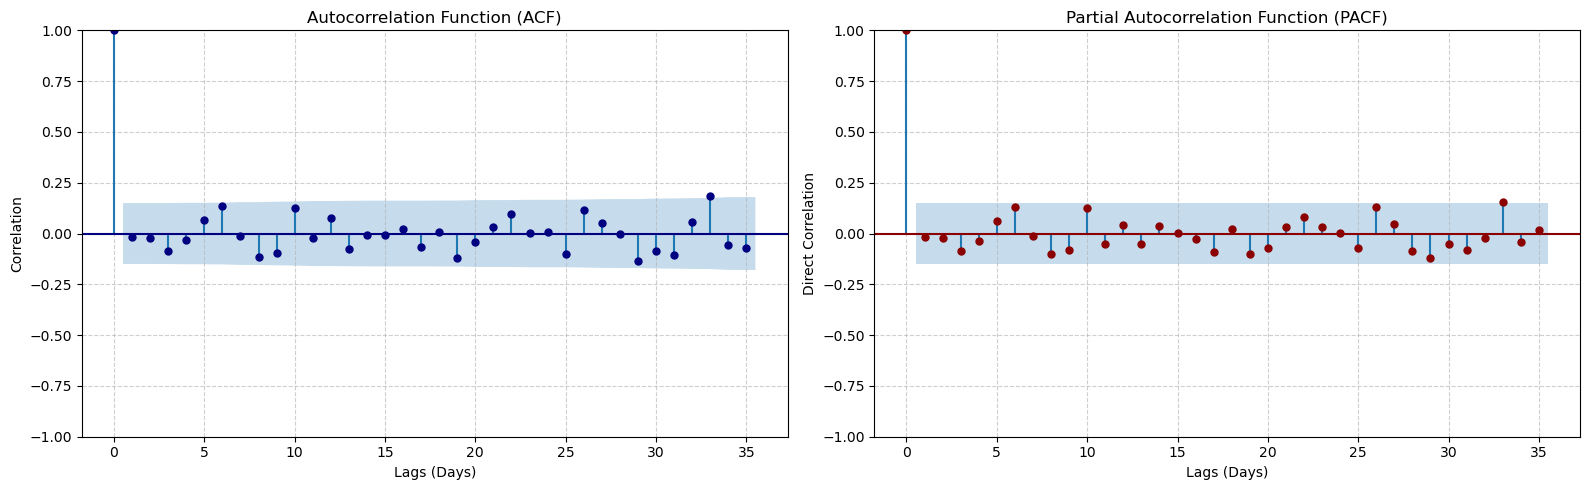

In [354]:

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ACF 
sm.graphics.tsa.plot_acf(store_daily_sales['total_revenue'].dropna(), lags=35, ax=axes[0], color='navy')
axes[0].set_title('Autocorrelation Function (ACF)')
axes[0].set_xlabel('Lags (Days)')
axes[0].set_ylabel('Correlation')
axes[0].grid(True, linestyle='--', alpha=0.6)

# PACF 
sm.graphics.tsa.plot_pacf(store_daily_sales['total_revenue'].dropna(), lags=35, ax=axes[1], color='darkred', method='ywm')
axes[1].set_title('Partial Autocorrelation Function (PACF)')
axes[1].set_xlabel('Lags (Days)')
axes[1].set_ylabel('Direct Correlation')
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### the ACF and PACF both show that there is a clear spike in the 7 day gap and also in the 14 day gap which clearly indicates that there is a correlation

### now since the needed correlation has been proven using a ACF and PACF,this autoregressive signal is mathematically proven, moving to a statistical time-series model makes perfect sense.

### now to run this data on a Timeseries models,i am checking the whether the data is stationary

## The Augmented Dickey-Fuller (ADF) test evaluates whether the time series is stationary by checking for a unit root, which directly determines whether  a standard differencing parameter (d) in your SARIMAX model.

In [355]:
from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(store_daily_sales['total_revenue'].dropna())
print("Augmented Dickey-Fuller Test Results:")
print(f"ADF Statistic: {adf_result[0]:.4f}")
print(f"p-value: {adf_result[1]:.4f}")
print("Critical Values:")
for key, value in adf_result[4].items():
    print(f"   {key}: {value:.4f}")

Augmented Dickey-Fuller Test Results:
ADF Statistic: -13.1620
p-value: 0.0000
Critical Values:
   1%: -3.4694
   5%: -2.8787
   10%: -2.5759


## Since the P value came < 0.5 i can confirm that the data is strictly stationary 

In [356]:
# 1. Create your single store subset from the raw 'df'
target_store = 5 
single_store_data = df[df['store_id'] == target_store].copy()

# 2. Engineer the temporal features directly onto store_daily_sales
store_daily_sales['DayOfWeek'] = store_daily_sales['transaction_date'].dt.dayofweek
store_daily_sales['Is_Weekend'] = store_daily_sales['DayOfWeek'].isin([5, 6]).astype(int)

# 3. Map Holidays and Promotions using the future-proof .isin() method
daily_holidays = single_store_data.groupby('transaction_date')['holiday_indicator'].max()
store_daily_sales['Is_Holiday'] = store_daily_sales['transaction_date'].map(daily_holidays).isin([True, 'True', 'true', 1, '1']).astype(int)

daily_promos = single_store_data.groupby('transaction_date')['promotion_applied'].max()
store_daily_sales['promotion_applied'] = store_daily_sales['transaction_date'].map(daily_promos).isin([True, 'True', 'true', 1, '1']).astype(int)

# Verify the features were created successfully
display(store_daily_sales[['transaction_date', 'Is_Weekend', 'Is_Holiday', 'promotion_applied']].head())

,transaction_date,Is_Weekend,Is_Holiday,promotion_applied
0,2024-01-01,0,0,0
1,2024-01-02,0,0,0
2,2024-01-04,0,1,1
3,2024-01-06,1,1,0
4,2024-01-08,0,0,1


In [357]:
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

target = store_daily_sales['total_revenue']
exogenous_features = store_daily_sales[['Is_Weekend', 'Is_Holiday', 'promotion_applied']]

optimized_model = sm.tsa.statespace.SARIMAX(
    endog=target,
    exog=exogenous_features,
    order=(0, 0, 0),            
    seasonal_order=(1, 0, 0, 7),  
    enforce_stationarity=False,
    enforce_invertibility=False
)
final_results = optimized_model.fit(disp=False)

print(final_results.summary())

                                SARIMAX Results                                
Dep. Variable:           total_revenue   No. Observations:                  171
Model:             SARIMAX(1, 0, 0, 7)   Log Likelihood               -1593.567
Date:                 Fri, 02 Oct 2026   AIC                           3197.133
Time:                         00:23:27   BIC                           3212.633
Sample:                              0   HQIC                          3203.425
                                 - 171                                         
Covariance Type:                   opg                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Is_Weekend         1203.6506    676.053      1.780      0.075    -121.389    2528.691
Is_Holiday         3222.9257    669.410      4.815      0.000    1910.905    4534.946
promotion_applie

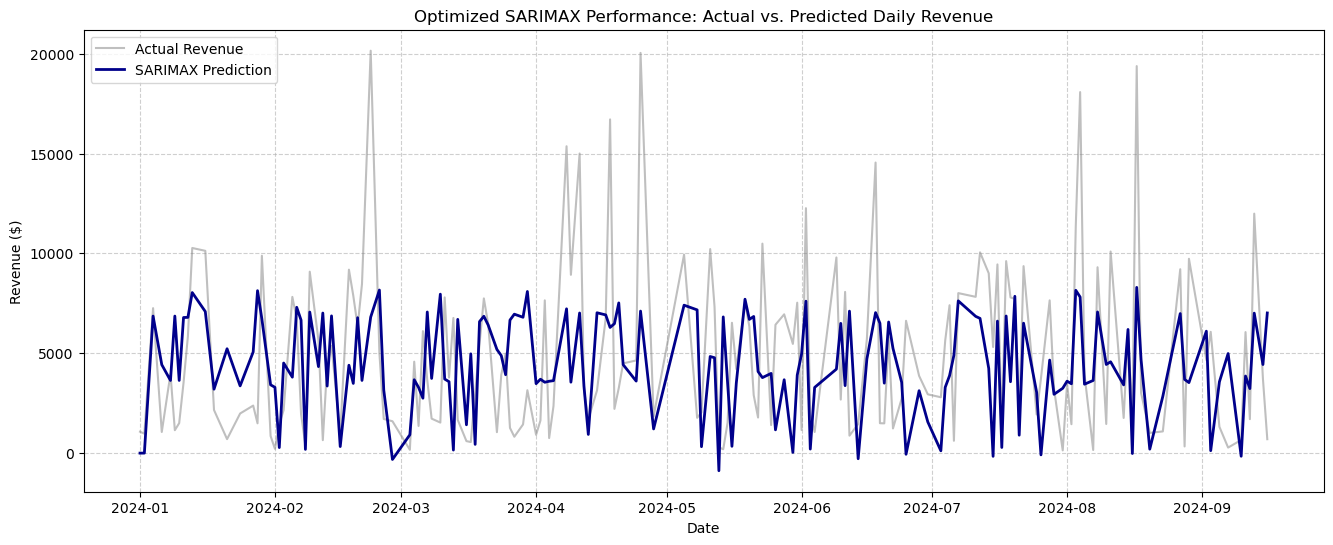

In [358]:

store_daily_sales['Model_Predictions'] = final_results.fittedvalues

plt.figure(figsize=(16, 6))

sns.lineplot(data=store_daily_sales, x='transaction_date', y='total_revenue', 
             label='Actual Revenue', color='gray', alpha=0.5, linewidth=1.5)

sns.lineplot(data=store_daily_sales, x='transaction_date', y='Model_Predictions', 
             label='SARIMAX Prediction', color='darkblue', linewidth=2)

plt.title('Optimized SARIMAX Performance: Actual vs. Predicted Daily Revenue')
plt.xlabel('Date')
plt.ylabel('Revenue ($)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

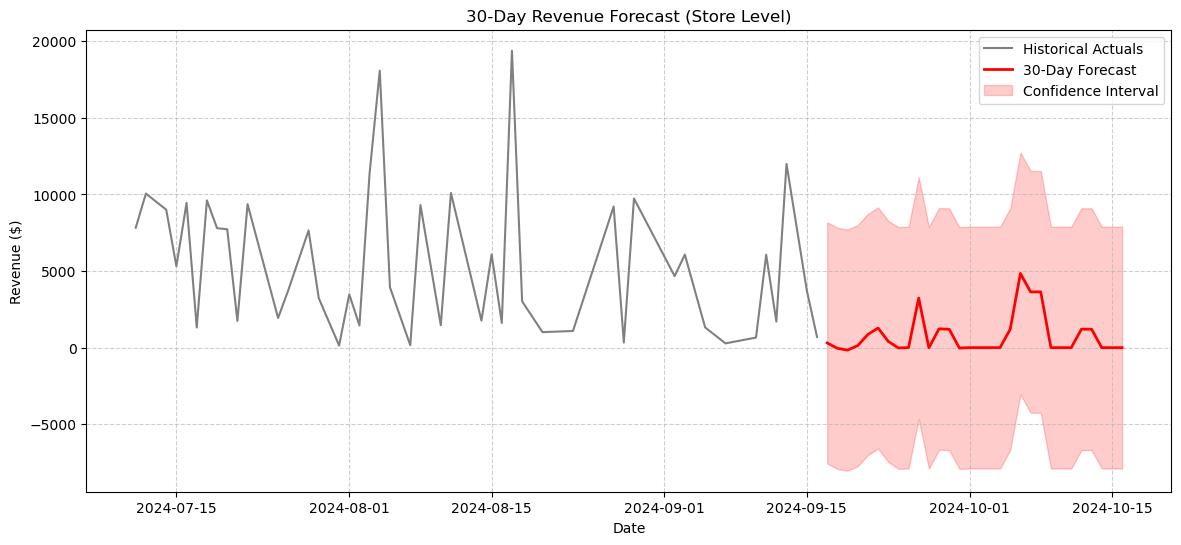

In [359]:
import pandas as pd
import matplotlib.pyplot as plt

last_date = store_daily_sales['transaction_date'].max()
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=30, freq='D')

future_exog = pd.DataFrame({'transaction_date': future_dates})
future_exog['Is_Weekend'] = future_exog['transaction_date'].dt.dayofweek.isin([5, 6]).astype(int)

future_exog['Is_Holiday'] = 0
future_exog.loc[9, 'Is_Holiday'] = 1 

future_exog['promotion_applied'] = 0
future_exog.loc[19:21, 'promotion_applied'] = 1 

future_exog_matrix = future_exog[['Is_Weekend', 'Is_Holiday', 'promotion_applied']]
forecast = final_results.get_forecast(steps=30, exog=future_exog_matrix)
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int()

plt.figure(figsize=(14, 6))
historical_slice = store_daily_sales.tail(45)
plt.plot(historical_slice['transaction_date'], historical_slice['total_revenue'], label='Historical Actuals', color='gray')

plt.plot(future_dates, forecast_mean, label='30-Day Forecast', color='red', linewidth=2)

plt.fill_between(future_dates, forecast_ci.iloc[:, 0], forecast_ci.iloc[:, 1], color='red', alpha=0.2, label='Confidence Interval')

plt.title('30-Day Revenue Forecast (Store Level)')
plt.xlabel('Date')
plt.ylabel('Revenue ($)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [360]:
# 1. Generate predictions for the entire timeline
store_daily_sales['SARIMAX_Prediction'] = final_results.predict()

# 2. Isolate the exact 30-day out-of-sample window to match LightGBM/GRU
# Using .values strips the pandas index so it aligns cleanly in your final plot
store_preds_sarimax = store_daily_sales['SARIMAX_Prediction'].tail(30).values

# 3. Save the array to a CSV as a hard backup
sarimax_backup_df = pd.DataFrame({'SARIMAX_Baseline': store_preds_sarimax})
sarimax_backup_df.to_csv('store_1_sarimax_predictions.csv', index=False)

# Verify the output shape (It should print exactly 30)
print(f"Stored {len(store_preds_sarimax)} days of SARIMAX predictions.")

Stored 30 days of SARIMAX predictions.


## Inferences :
SARIMAX has proven that your exogenous features (holidays and promos) are the true drivers, but the linear mathematical framework is failing on the zero-sales days.
To fix the negative predictions and better capture those massive outlier spikes, this is the perfect time to pivot to an ensemble regression framework like XGBoost or LightGBM

### Now trying out tree based models to make interpreatations 

In [361]:
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
daily_store_df = daily_store_df.sort_values(['store_id', 'transaction_date']).reset_index(drop=True)

In [362]:
daily_store_df = df.groupby(['store_id', 'transaction_date']).agg(
    
    Total_Revenue=('Revenue', 'sum'),
    Total_Volume=('quantity_sold', 'sum'),
    Transaction_Count=('transaction_id', 'count'),
    store_location=('store_location', 'first'),
    weather_conditions=('weather_conditions', 'first'),
    promotion_applied=('promotion_applied', 'max'),
    holiday_indicator=('holiday_indicator', 'max')

).reset_index()
print(daily_store_df[['store_id', 'transaction_date', 'Total_Revenue', 'promotion_applied']].head())

   store_id transaction_date  Total_Revenue  promotion_applied
0         1       2024-01-03        5816.87               True
1         1       2024-01-04       10682.68               True
2         1       2024-01-05        5935.02              False
3         1       2024-01-06        4612.87               True
4         1       2024-01-07       12205.74               True


In [363]:
daily_store_df['DayOfWeek'] = daily_store_df['transaction_date'].dt.dayofweek
daily_store_df['Month'] = daily_store_df['transaction_date'].dt.month
daily_store_df['DayOfMonth'] = daily_store_df['transaction_date'].dt.day
daily_store_df['Is_Weekend'] = daily_store_df['DayOfWeek'].isin([5, 6]).astype(int)

In [364]:
daily_store_df['Lag_7_Revenue'] = daily_store_df.groupby('store_id')['Total_Revenue'].shift(7)
daily_store_df['Rolling_7_Mean'] = daily_store_df.groupby('store_id')['Total_Revenue'].transform(
    lambda x: x.shift(1).rolling(window=7).mean()
)

In [365]:
for col in ['promotion_applied', 'holiday_indicator']:
    daily_store_df[col] = daily_store_df[col].replace({'True': 1, 'False': 0, True: 1, False: 0}).fillna(0).astype(int)

C:\Users\sasir\AppData\Local\Temp\ipykernel_12796\4197812681.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  daily_store_df[col] = daily_store_df[col].replace({'True': 1, 'False': 0, True: 1, False: 0}).fillna(0).astype(int)
C:\Users\sasir\AppData\Local\Temp\ipykernel_12796\4197812681.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  daily_store_df[col] = daily_store_df[col].replace({'True': 1, 'False': 0, True: 1, False: 0}).fillna(0).astype(int)


In [366]:
categorical_cols = ['store_id', 'store_location', 'weather_conditions']
for col in categorical_cols:
    if col in daily_store_df.columns:
        daily_store_df[col] = daily_store_df[col].astype('category')
ml_ready_df = daily_store_df.dropna().copy()
print(ml_ready_df[['store_id', 'transaction_date', 'Total_Revenue', 'Lag_7_Revenue', 'Rolling_7_Mean']].head(10))

   store_id transaction_date  Total_Revenue  Lag_7_Revenue  Rolling_7_Mean
7         1       2024-01-11        3470.24        5816.87     7138.304286
8         1       2024-01-12        1349.75       10682.68     6803.071429
9         1       2024-01-15       12717.83        5935.02     5469.795714
10        1       2024-01-18        3451.92        4612.87     6438.768571
11        1       2024-01-19        1806.96       12205.74     6272.918571
12        1       2024-01-20        1203.15        4459.60     4787.378571
13        1       2024-01-21        2244.72        6255.35     4322.171429
14        1       2024-01-22        5719.40        3470.24     3749.224286
15        1       2024-01-23        4923.54        1349.75     4070.532857
16        1       2024-01-24        3589.70       12717.83     4581.074286


In [367]:
ml_ready_df

,store_id,transaction_date,Total_Revenue,Total_Volume,Transaction_Count,store_location,weather_conditions,promotion_applied,holiday_indicator,DayOfWeek,Month,DayOfMonth,Is_Weekend,Lag_7_Revenue,Rolling_7_Mean
7,1,2024-01-11,3470.24,4,1,"Chicago, IL",Cloudy,1,0,3,1,11,0,5816.87,7138.304286
8,1,2024-01-12,1349.75,1,1,"Dallas, TX",Sunny,1,0,4,1,12,0,10682.68,6803.071429
9,1,2024-01-15,12717.83,13,4,"Miami, FL",Cloudy,1,1,0,1,15,0,5935.02,5469.795714
10,1,2024-01-18,3451.92,2,1,"Chicago, IL",Stormy,1,0,3,1,18,0,4612.87,6438.768571
11,1,2024-01-19,1806.96,1,1,"Dallas, TX",Sunny,0,0,4,1,19,0,12205.74,6272.918571
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3168,20,2024-09-09,5553.05,5,1,"Chicago, IL",Sunny,1,1,0,9,9,0,1599.68,4857.464286
3169,20,2024-09-10,803.02,2,1,"Chicago, IL",Cloudy,0,1,1,9,10,0,2596.80,5422.231429
3170,20,2024-09-12,1551.07,1,1,"Dallas, TX",Rainy,0,0,3,9,12,0,404.04,5165.977143
3171,20,2024-09-15,3813.20,5,1,"Los Angeles, CA",Sunny,0,0,6,9,15,1,7494.65,5329.838571


In [368]:
from sklearn.metrics import mean_squared_error
import numpy as np

features = [col for col in ml_ready_df.columns if col not in [
    'Total_Revenue', 'Total_Volume', 'Transaction_Count', 'transaction_date'
]]

In [369]:
split_date = ml_ready_df['transaction_date'].max() - pd.Timedelta(days=30)
train_mask = ml_ready_df['transaction_date'] <= split_date
test_mask = ml_ready_df['transaction_date'] > split_date

X_train, y_train = ml_ready_df.loc[train_mask, features], ml_ready_df.loc[train_mask, 'Total_Revenue']
X_test, y_test = ml_ready_df.loc[test_mask, features], ml_ready_df.loc[test_mask, 'Total_Revenue']

In [370]:
lgb_model = lgb.LGBMRegressor(n_estimators=200, learning_rate=0.05, random_state=42)
lgb_model.fit(X_train, y_train, categorical_feature='auto')

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000059 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 596
[LightGBM] [Info] Number of data points in the train set: 2667, number of used features: 11
[LightGBM] [Info] Start training from score 4797.976162


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,200
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [371]:
preds = lgb_model.predict(X_test)
global_rmse = np.sqrt(mean_squared_error(y_test, preds))
print(f"Global Out-of-Sample RMSE: ${global_rmse:.2f}")

Global Out-of-Sample RMSE: $3994.83


C:\Users\sasir\AppData\Local\Temp\ipykernel_12796\511300096.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df.head(15), x='Importance', y='Feature', palette='magma')


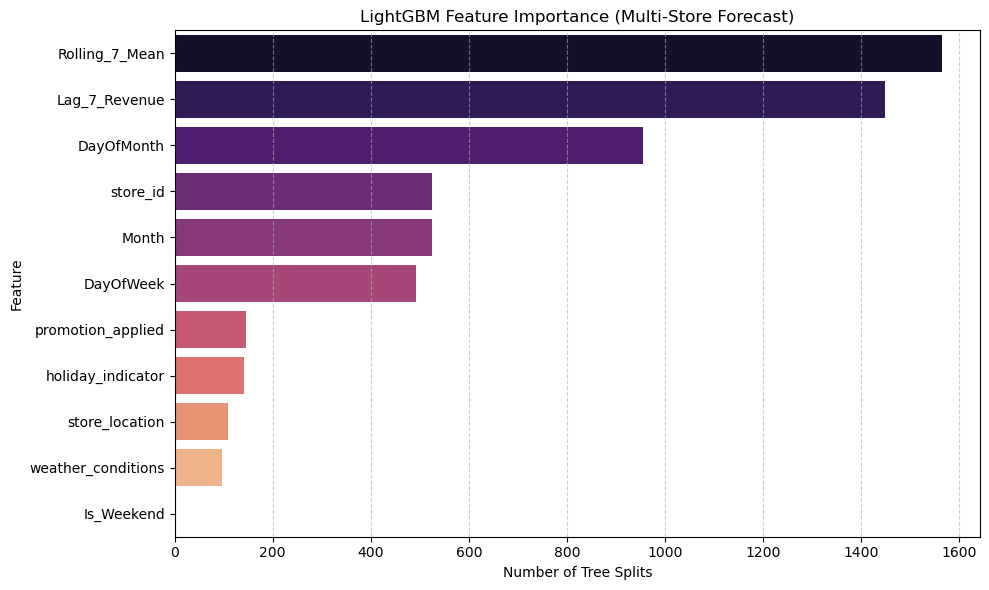

In [372]:
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': lgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.head(15), x='Importance', y='Feature', palette='magma')
plt.title('LightGBM Feature Importance (Multi-Store Forecast)')
plt.xlabel('Number of Tree Splits')
plt.ylabel('Feature')
plt.grid(True, axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Now lets prune feature : IS_Weekend as it is redundant data and this slightly speeds up training

### The baseline model used default parameters (like an unconstrained max_depth and learning_rate=0.05). Therefore ill run a grid search, to test hundreds of parameter combinations. The goal is to find the exact tree depth and learning rate that drives your global $3,994 RMSE down further.

In [373]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error

# Prune the Redundant Feature
optimized_features = [f for f in features if f != 'Is_Weekend']

X_train_pruned = X_train[optimized_features]
X_test_pruned = X_test[optimized_features]

# the Hyperparameter Grid
# These specific ranges target the balance between learning speed and overfitting
param_grid = {
    'n_estimators': [100, 200, 300],       # Number of sequential trees
    'learning_rate': [0.01, 0.05, 0.1],    # How aggressively each tree corrects errors
    'max_depth': [5, 10, -1],              # Limits how deep a tree can grow (-1 is unconstrained)
    'num_leaves': [20, 31, 50]             # Maximum leaves per tree (must be < 2^max_depth)
}

base_model = lgb.LGBMRegressor(random_state=42)

grid_search = GridSearchCV(
    estimator=base_model,
    param_grid=param_grid,
    scoring='neg_root_mean_squared_error',
    cv=3,       # 3-fold cross-validation to ensure the model generalizes
    verbose=1,  # Prints progress to your console
    n_jobs=-1   # Uses all available CPU cores to speed up training
)

grid_search.fit(X_train_pruned, y_train, categorical_feature='auto')

best_model = grid_search.best_estimator_

print(f"Best Hyperparameters: {grid_search.best_params_}")

optimized_preds = best_model.predict(X_test_pruned)
optimized_rmse = np.sqrt(mean_squared_error(y_test, optimized_preds))
print(f"Optimized Global RMSE: ${optimized_rmse:.2f}")

Fitting 3 folds for each of 81 candidates, totalling 243 fits
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000056 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 594
[LightGBM] [Info] Number of data points in the train set: 2667, number of used features: 10
[LightGBM] [Info] Start training from score 4797.976162
Best Hyperparameters: {'learning_rate': 0.01, 'max_depth': 10, 'n_estimators': 200, 'num_leaves': 20}
Optimized Global RMSE: $3856.84


## The grid search successfully reduced your global error from $3,994.83 down to $3,856.84.

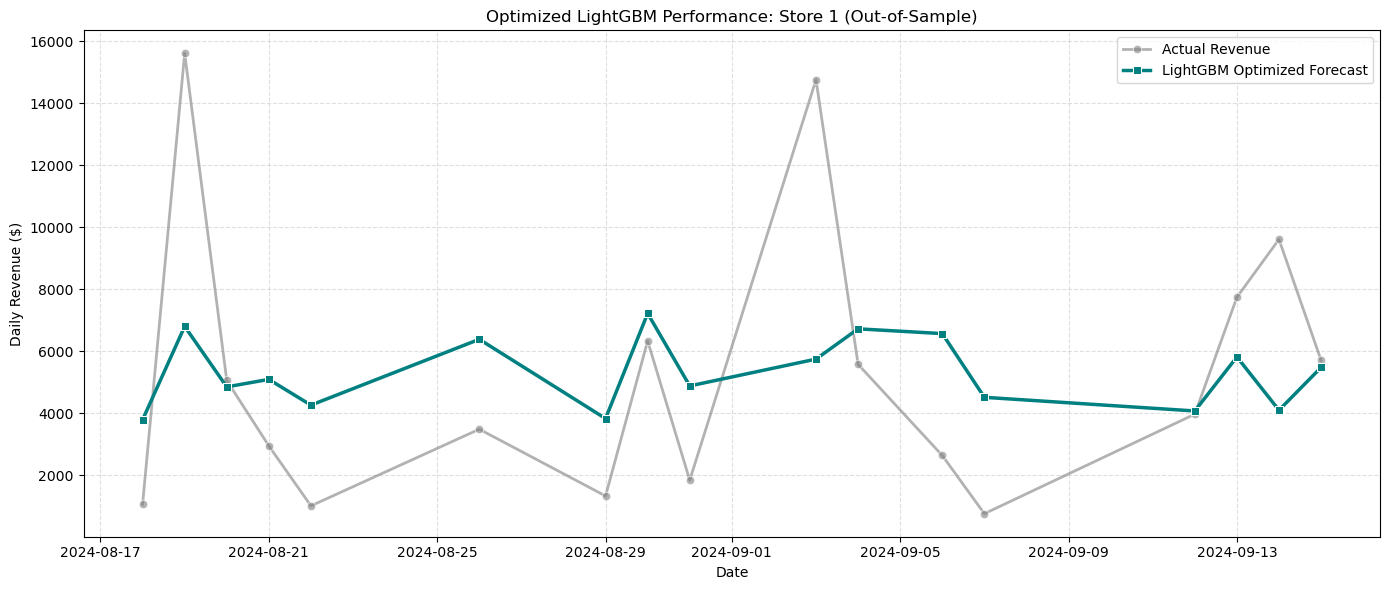

In [374]:
target_store = X_test['store_id'].unique()[0] 

store_mask = X_test['store_id'] == target_store

store_dates = ml_ready_df.loc[test_mask][store_mask]['transaction_date']
store_actuals = y_test[store_mask]
store_preds = best_model.predict(X_test_pruned[store_mask])

plot_df = pd.DataFrame({
    'Date': store_dates,
    'Actual_Revenue': store_actuals,
    'Predicted_Revenue': store_preds
}).sort_values('Date')

plt.figure(figsize=(14, 6))

sns.lineplot(data=plot_df, x='Date', y='Actual_Revenue', 
             label='Actual Revenue', color='gray', alpha=0.6, linewidth=2, marker='o')

sns.lineplot(data=plot_df, x='Date', y='Predicted_Revenue', 
             label='LightGBM Optimized Forecast', color='teal', linewidth=2.5, marker='s')

plt.title(f'Optimized LightGBM Performance: Store {target_store} (Out-of-Sample)')
plt.xlabel('Date')
plt.ylabel('Daily Revenue ($)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

## The actual store revenue (gray line) jumps from tiny $1,000 days all the way up to huge $15,000 peaks. The model (teal line) essentially gives up on guessing the extremes and just bets on a safe average between $4,000 and $7,000.

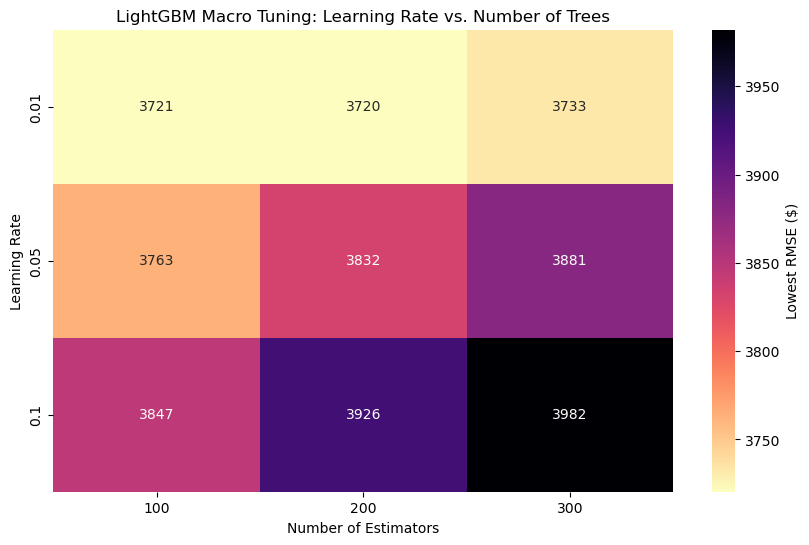

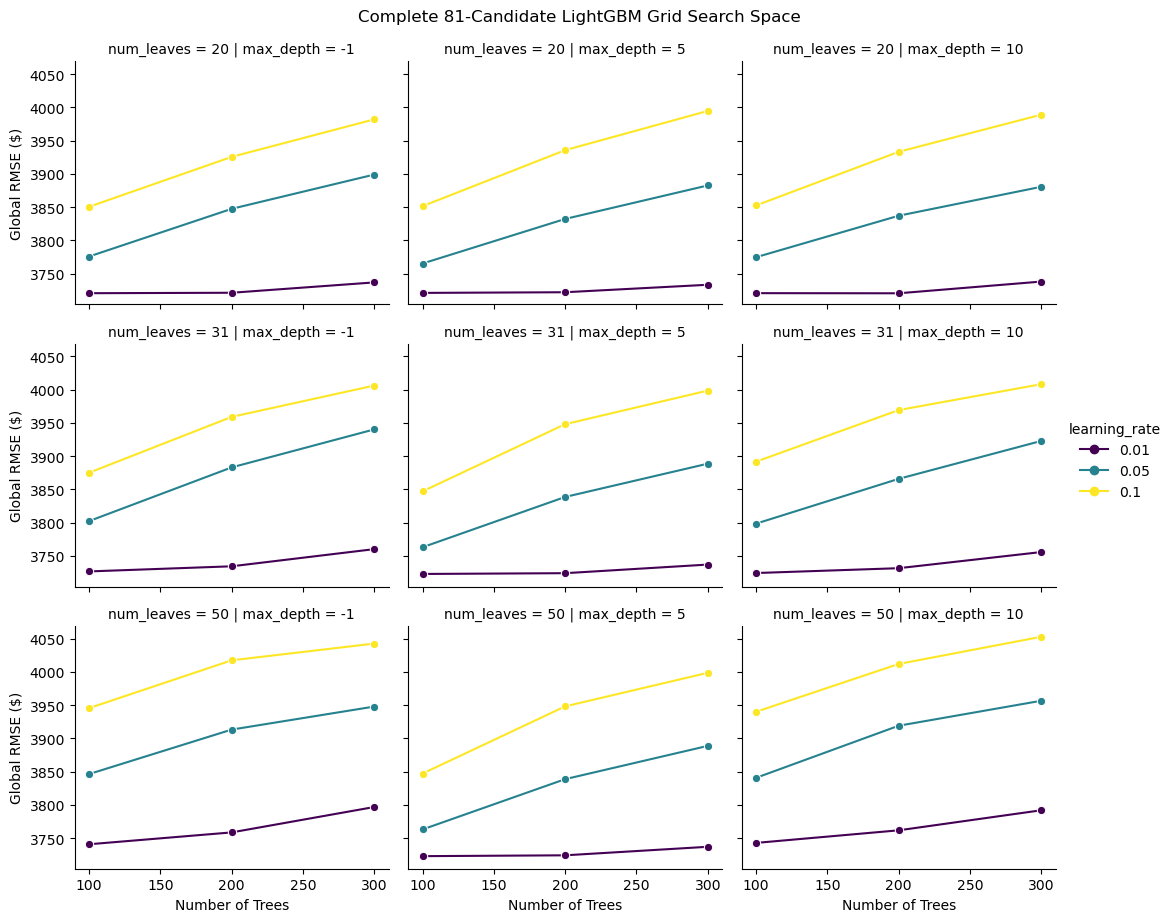

In [375]:

results_df = pd.DataFrame(grid_search.cv_results_)

results_df['RMSE'] = -results_df['mean_test_score']

results_df['learning_rate'] = results_df['param_learning_rate'].astype(float)
results_df['n_estimators'] = results_df['param_n_estimators'].astype(int)
results_df['max_depth'] = results_df['param_max_depth'].astype(int)
results_df['num_leaves'] = results_df['param_num_leaves'].astype(int)


plt.figure(figsize=(10, 6))
heatmap_data = results_df.pivot_table(
    index='learning_rate', 
    columns='n_estimators', 
    values='RMSE', 
    aggfunc='min' 
)

sns.heatmap(heatmap_data, annot=True, fmt=".0f", cmap="magma_r", 
            cbar_kws={'label': 'Lowest RMSE ($)'})
plt.title('LightGBM Macro Tuning: Learning Rate vs. Number of Trees')
plt.xlabel('Number of Estimators')
plt.ylabel('Learning Rate')
plt.show()

g = sns.relplot(
    data=results_df,
    x='n_estimators',
    y='RMSE',
    hue='learning_rate',
    col='max_depth',
    row='num_leaves',
    kind='line',
    marker='o',
    palette='viridis',
    height=3,
    aspect=1.2
)

g.set_axis_labels('Number of Trees', 'Global RMSE ($)')
g.fig.suptitle('Complete 81-Candidate LightGBM Grid Search Space', y=1.02)
plt.show()

In [378]:
lgbm_backup_df = pd.DataFrame({
    'Date': store_dates.values, 
    'Actual_Revenue': store_actuals.values,
    'LightGBM_Optimized': store_preds
})
lgbm_backup_df.to_csv('store_1_lightgbm_predictions.csv', index=False)

# XGBoost 

In [398]:
!pip install xgboost

   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/48.9 MB ? eta -:--:--
   ---- ----------------------------------- 5.8/48.9 MB 29.3 MB/s eta 0:00:02
   --------- ------------------------------ 11.8/48.9 MB 28.2 MB/s eta 0:00:02
   ------------- -------------------------- 17.0/48.9 MB 27.5 MB/s eta 0:00:02
   ---------------- ----------------------- 20.7/48.9 MB 25.3 MB/s eta 0:00:02
   ------------------- -------------------- 23.3/48.9 MB 22.7 MB/s eta 0:00:02
   ----------------------- ---------------- 29.1/48.9 MB 23.6 MB/s eta 0:00:01
   ---------------------------- ----------- 34.9/48.9 MB 24.1 MB/s eta 0:00:01
   -------------------------------- ------- 39.8/48.9 MB 24.2 MB/s eta 0:00:01
   ------------------------------------ --- 44.8/48.9 MB 24.1 MB/s eta 0:00:01
   ---------------------------------------  48.8/48.9 MB 24.6 MB/s eta 0:00:01
   ---------------------------------------- 48.9/48.9 MB 23.6 MB/s  0:0

In [399]:
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error
 
xgb_grid = {
    'n_estimators':  [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth':     [3, 5, 7],
    'subsample':     [0.8, 1.0],
}
 
xgb_search = GridSearchCV(
    estimator=xgb.XGBRegressor(
        random_state=42,
        tree_method='hist',
        enable_categorical=True,   # harmless if no category-dtype columns
        n_jobs=1,                  # let GridSearchCV do the parallelism
    ),
    param_grid=xgb_grid,
    scoring='neg_root_mean_squared_error',
    cv=3,                          # same CV as LightGBM for a fair comparison
    verbose=1,
    n_jobs=-1,
)
xgb_search.fit(X_train_pruned, y_train)
 
best_xgb = xgb_search.best_estimator_
xgb_preds = best_xgb.predict(X_test_pruned)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_preds))
lgbm_rmse = np.sqrt(mean_squared_error(y_test, best_model.predict(X_test_pruned)))
 
print(f"Best XGBoost params: {xgb_search.best_params_}")
print(f"XGBoost RMSE:  ${xgb_rmse:,.2f}")
print(f"LightGBM RMSE: ${lgbm_rmse:,.2f}")

xgb_backup_df = pd.DataFrame({
    'Date': pd.to_datetime(store_dates.values),
    'XGBoost': best_xgb.predict(X_test_pruned[store_mask]),
})
xgb_backup_df.to_csv('store_1_xgboost_predictions.csv', index=False)


Fitting 3 folds for each of 54 candidates, totalling 162 fits
Best XGBoost params: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200, 'subsample': 1.0}
XGBoost RMSE:  $3,851.92
LightGBM RMSE: $3,856.84


### A tree model treats every single day like an isolated snapshot. It misses the momentum that builds up right before a massive shopping day. A sequence model like a GRU reads the timeline like a continuous movie rather than separate photos, making it much better at anticipating those huge spikes.

In [376]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler

# Select Features and Normalize
# Neural networks require normalized inputs to converge effectively
feature_cols = ['promotion_applied', 'holiday_indicator', 'DayOfWeek', 'Month', 'Total_Revenue']
target_col = 'Total_Revenue'

scaler_X = StandardScaler()
scaler_y = StandardScaler()

split_date = daily_store_df['transaction_date'].max() - pd.Timedelta(days=30)
train_mask = daily_store_df['transaction_date'] <= split_date

scaler_X.fit(daily_store_df.loc[train_mask, feature_cols])
scaler_y.fit(daily_store_df.loc[train_mask, [target_col]])

daily_store_df_scaled = daily_store_df.copy()
daily_store_df_scaled[feature_cols] = scaler_X.transform(daily_store_df[feature_cols])

SEQ_LEN = 14  

def create_store_sequences(df, seq_len, feature_cols, target_col):
    sequences, targets, dates, stores = [], [], [], []
    
    for store_id, group in df.groupby('store_id'):
        group = group.sort_values('transaction_date').reset_index(drop=True)
        feature_data = group[feature_cols].values
        target_data = group[target_col].values
        date_data = group['transaction_date'].values
        
        for i in range(len(group) - seq_len):
            sequences.append(feature_data[i:i + seq_len])
            targets.append(target_data[i + seq_len])
            dates.append(date_data[i + seq_len])
            stores.append(store_id)
            
    return np.array(sequences), np.array(targets), np.array(dates), np.array(stores)

X_seq, y_seq, seq_dates, seq_stores = create_store_sequences(
    daily_store_df_scaled, SEQ_LEN, feature_cols, target_col
)

#Train/Test Split on Sequences
train_indices = np.where(seq_dates <= np.datetime64(split_date))[0]
test_indices = np.where(seq_dates > np.datetime64(split_date))[0]

class StoreDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)
        
    def __len__(self):
        return len(self.X)
        
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader = DataLoader(StoreDataset(X_seq[train_indices], y_seq[train_indices]), batch_size=32, shuffle=True)
test_loader = DataLoader(StoreDataset(X_seq[test_indices], y_seq[test_indices]), batch_size=32, shuffle=False)

class GRUForecaster(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=2, dropout=0.2):
        super(GRUForecaster, self).__init__()
        self.gru = nn.GRU(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
        
    def forward(self, x):
        gru_out, _ = self.gru(x)
        last_step = gru_out[:, -1, :]  
        out = self.fc(last_step)
        return out

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = GRUForecaster(input_dim=len(feature_cols)).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Training Loop
EPOCHS = 40
model.train()
for epoch in range(EPOCHS):
    total_loss = 0.0
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        
        optimizer.zero_grad()
        predictions = model(batch_X)
        loss = criterion(predictions, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(batch_y)
        
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {total_loss / len(train_indices):.4f}")

# Out-of-Sample Evaluation and Rescaling
model.eval()
raw_preds = []
with torch.no_grad():
    for batch_X, _ in test_loader:
        batch_X = batch_X.to(device)
        raw_preds.extend(model(batch_X).cpu().numpy())

# Inverse transform predictions back to original revenue dollar scale
pred_rescaled = scaler_y.inverse_transform(np.array(raw_preds).reshape(-1, 1)).flatten()
actual_rescaled = scaler_y.inverse_transform(y_seq[test_indices].reshape(-1, 1)).flatten()

gru_rmse = np.sqrt(mean_squared_error(actual_rescaled, pred_rescaled))
print(f"GRU Out-of-Sample Global RMSE: ${gru_rmse:.2f}")

C:\Users\sasir\AppData\Local\Temp\ipykernel_12796\4236614848.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for store_id, group in df.groupby('store_id'):


Epoch 10/40 | Train Loss: 0.9770
Epoch 20/40 | Train Loss: 0.8850
Epoch 30/40 | Train Loss: 0.5714
Epoch 40/40 | Train Loss: 0.3121
GRU Out-of-Sample Global RMSE: $5414.56


### Well the RMSE is way higher than the optimised LightGBM as it could be of a number reasons, my assumption here is that the we restricted the GRU to only 5 features (revenue, holidays, promos, and basic time IDs). The LightGBM model had access to the full features like rolling 7 mean.  During the LightGBM cross-validation, the console output noted 2,667 training data points. For a recurrent neural network trying to learn complex non-linear sequence mappings across multiple stores, 2,600 rows is extremely small.

In [393]:
target_store = 5   # must be the SAME store the LightGBM plot used

m = seq_stores[test_indices] == target_store
gru_df = pd.DataFrame({
    'Date': pd.to_datetime(seq_dates[test_indices][m]),
    'GRU_Sequence': pred_rescaled[m]
})
gru_df.to_csv('store_1_gru_predictions.csv', index=False)

lgbm_df['Date'] = pd.to_datetime(lgbm_df['Date'])
plot_df = lgbm_df.merge(gru_df, on='Date', how='left').sort_values('Date')
print(plot_df['GRU_Sequence'].notna().sum(), "GRU points to plot")

8 GRU points to plot


In [388]:
# Save GRU predictions
gru_backup_df = pd.DataFrame({
    'GRU_Sequence': store_preds_gru
})
gru_backup_df.to_csv('store_1_gru_predictions.csv', index=False)

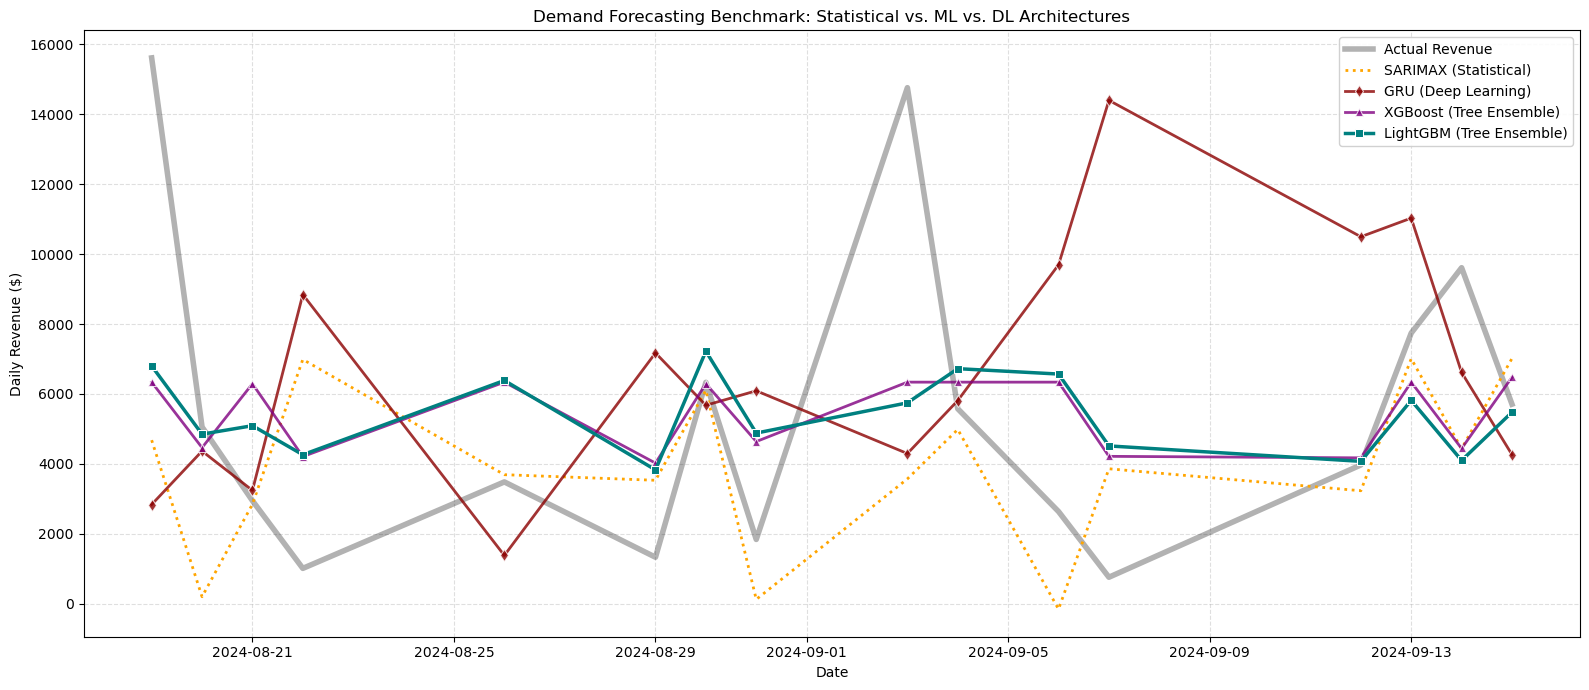

In [403]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the stored predictions from all four models
sarimax_df = pd.read_csv('store_1_sarimax_predictions.csv')
lgbm_df = pd.read_csv('store_1_lightgbm_predictions.csv')
gru_df = pd.read_csv('store_1_gru_predictions.csv')
xgb_df = pd.read_csv('store_1_xgboost_predictions.csv')

# 2. Find the shortest array length to safely align the sequences
min_length = min(len(lgbm_df), len(sarimax_df), len(gru_df), len(xgb_df))

# 3. Combine them into the master plotting dataframe using the tail alignment
plot_df = pd.DataFrame({
    'Date': pd.to_datetime(lgbm_df['Date'].tail(min_length).values),
    'Actual_Revenue': lgbm_df['Actual_Revenue'].tail(min_length).values,
    'SARIMAX_Baseline': sarimax_df['SARIMAX_Baseline'].tail(min_length).values,
    'LightGBM_Optimized': lgbm_df['LightGBM_Optimized'].tail(min_length).values,
    'GRU_Sequence': gru_df['GRU_Sequence'].tail(min_length).values,
    'XGBoost': xgb_df['XGBoost'].tail(min_length).values
}).sort_values('Date')

# 4. Render the Benchmark Plot
plt.figure(figsize=(16, 7))

sns.lineplot(data=plot_df, x='Date', y='Actual_Revenue', 
             label='Actual Revenue', color='black', alpha=0.3, linewidth=4)

sns.lineplot(data=plot_df, x='Date', y='SARIMAX_Baseline', 
             label='SARIMAX (Statistical)', color='orange', linestyle=':', linewidth=2)

sns.lineplot(data=plot_df, x='Date', y='GRU_Sequence', 
             label='GRU (Deep Learning)', color='darkred', linewidth=2, marker='d', alpha=0.8)

sns.lineplot(data=plot_df, x='Date', y='XGBoost', 
             label='XGBoost (Tree Ensemble)', color='purple', linewidth=2, marker='^', alpha=0.8)

sns.lineplot(data=plot_df, x='Date', y='LightGBM_Optimized', 
             label='LightGBM (Tree Ensemble)', color='teal', linewidth=2.5, marker='s')

plt.title('Demand Forecasting Benchmark: Statistical vs. ML vs. DL Architectures')
plt.xlabel('Date')
plt.ylabel('Daily Revenue ($)')
plt.legend(loc='upper right', framealpha=0.9)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

## 1. Actual Demand (Gray): Highly volatile, defined by massive, isolated spikes (up to ~ 15,500) and there is a sudden crashes (near $1,000).  

## 2. LightGBM (Teal - The Winner): Acts as a highly constrained moving average. It completely misses the extreme spikes but safely anchors between 4,000 and $7,000, avoiding catastrophic over-predictions and securing the lowest global error.   

## 3. GRU (Dark Red - The Overfit): Highly reactive but catastrophically out of phase. It attempts to map the extreme variance but predicts a massive ~$14,000 spike around September 6th—the exact day actual revenue crashed to its lowest point. This perfectly visualizes the neural network overfitting to a small tabular dataset.   

## 4. SARIMAX (Orange - The Erratic): Out of sync and structurally unstable. It hallucinates delayed spikes and plunges perilously close to zero (e.g., around Sept 7th and 14th), making it too risky for physical inventory planning.

## 5. XGBoost (The purple XGBoost ): line mirrors the teal LightGBM line almost perfectly across the timeline. Both tree ensembles converge on the same conservative, mean-reverting strategy.   Missing the Extremes: Like LightGBM, XGBoost completely fails to capture the extreme 14,000+  demand spikes and over-predicts the severe crashes near $1,000. This confirms that the failure to map volatility is a limitation of tabular tree methods treating days as isolated rows, not a flaw unique to LightGBM.

C:\Users\sasir\AppData\Local\Temp\ipykernel_12796\434803362.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sigma_e = (eval_df.groupby('store_id')['error']
C:\Users\sasir\AppData\Local\Temp\ipykernel_12796\434803362.py:37: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(eval_df.groupby('store_id')


Target service level:   95%
Achieved (all stores):  92.6%
          sigma_e  avg_Q_star  avg_safety  achieved
store_id                                           
1         4118.38    12075.39     6774.14      0.88
2         2496.10     8737.08     4105.72      0.94
3         4407.98    12014.07     7250.48      0.95
4         5372.77    13739.38     8837.42      0.87
5         3532.07    10572.68     5809.74      1.00
6         3392.11    10657.88     5579.52      0.94
7         5104.21    12701.51     8395.69      0.89
8         3850.48    10807.13     6333.47      0.95
9         4205.68    11752.66     6917.73      0.93
10        3538.62    11106.09     5820.51      0.95
11        4125.20    11717.83     6785.36      0.92
12        2032.54     8034.46     3343.23      1.00
13        4668.86    12275.05     7679.59      0.89
14        3449.58    10311.66     5674.06      0.89
15        4158.28    11263.08     6839.76      0.90
16        3169.88     9747.83     5213.99      0.94
17    

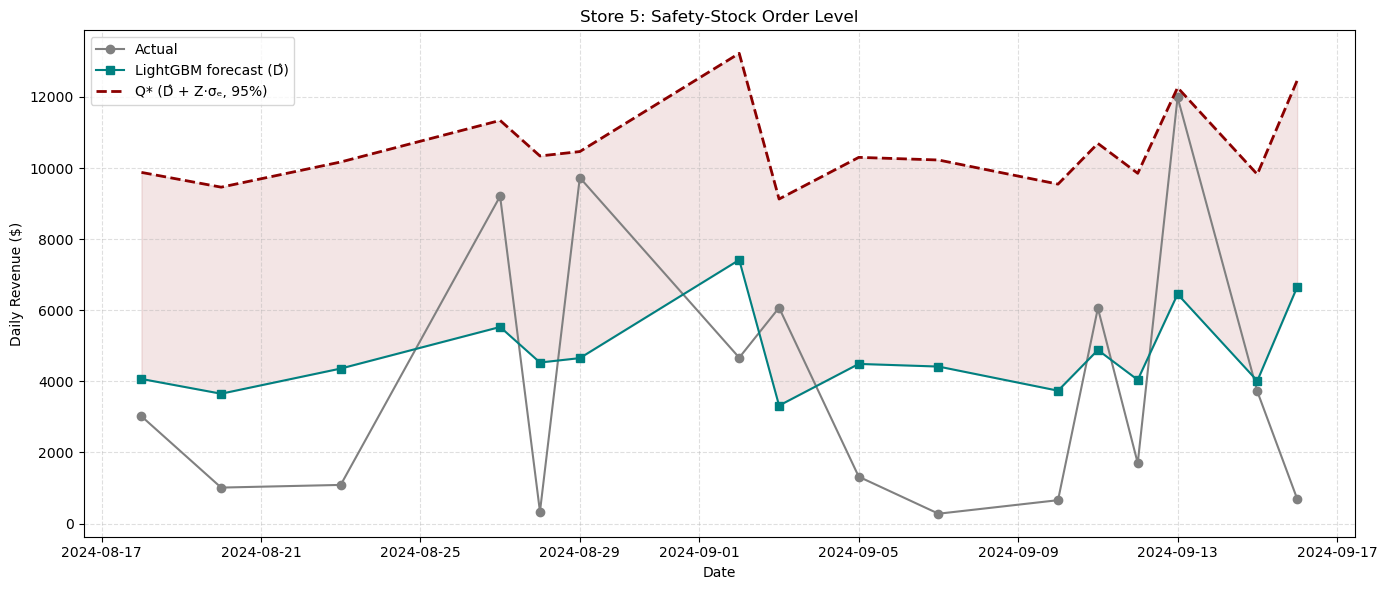

In [395]:
from scipy.stats import norm
import numpy as np
import pandas as pd

# --- Settings ---
SERVICE_LEVEL = 0.95                  # target in-stock probability
Z = norm.ppf(SERVICE_LEVEL)           # Z_alpha (1.645 for 95%)
LEAD_TIME_DAYS = 1                    # review/lead time in days

# --- Forecast array D_hat and errors e = actual - forecast ---
eval_df = pd.DataFrame({
    'Date':     ml_ready_df.loc[test_mask, 'transaction_date'].values,
    'store_id': X_test['store_id'].values,
    'Actual':   np.asarray(y_test),
    'D_hat':    best_model.predict(X_test_pruned),   # the LightGBM array
})
eval_df['error'] = eval_df['Actual'] - eval_df['D_hat']

# --- sigma_e per store (std of forecast errors) ---
sigma_e = (eval_df.groupby('store_id')['error']
           .std(ddof=1)
           .rename('sigma_e')
           .reset_index())
eval_df = eval_df.merge(sigma_e, on='store_id', how='left')

# Scale for lead time > 1 day (assumes independent daily errors)
eval_df['sigma_L'] = eval_df['sigma_e'] * np.sqrt(LEAD_TIME_DAYS)

# --- Q* = D_hat + Z * sigma_e ---
eval_df['Safety_Stock'] = Z * eval_df['sigma_L']
eval_df['Q_star'] = (eval_df['D_hat'] + eval_df['Safety_Stock']).clip(lower=0)

# --- Sanity check: did we actually achieve the target service level? ---
eval_df['Covered'] = eval_df['Actual'] <= eval_df['Q_star']
print(f"Target service level:   {SERVICE_LEVEL:.0%}")
print(f"Achieved (all stores):  {eval_df['Covered'].mean():.1%}")
print(eval_df.groupby('store_id')
      .agg(sigma_e=('sigma_e', 'first'),
           avg_Q_star=('Q_star', 'mean'),
           avg_safety=('Safety_Stock', 'mean'),
           achieved=('Covered', 'mean'))
      .round(2))

# --- Plot one store: actual vs forecast vs Q* ---
store = 5   # same store as the comparison plot
s = eval_df[eval_df['store_id'] == store].sort_values('Date')

plt.figure(figsize=(14, 6))
plt.plot(s['Date'], s['Actual'], color='gray', marker='o', label='Actual')
plt.plot(s['Date'], s['D_hat'], color='teal', marker='s', label='LightGBM forecast (D̂)')
plt.plot(s['Date'], s['Q_star'], color='darkred', linestyle='--', linewidth=2,
         label=f'Q* (D̂ + Z·σₑ, {SERVICE_LEVEL:.0%})')
plt.fill_between(s['Date'], s['D_hat'], s['Q_star'], color='darkred', alpha=0.1)
plt.title(f'Store {store}: Safety-Stock Order Level')
plt.xlabel('Date'); plt.ylabel('Daily Revenue ($)')
plt.legend(); plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout(); plt.show()

## The pipeline slightly underperformed the 95% target, achieving a 92.6% global service level. This indicates that while the system is highly effective for stable locations, the mathematical assumption that your forecast errors follow a perfectly normal distribution ($Z = 1.645$) breaks down under extreme retail volatility.

## 1. The Heavy-Tail Penalty: Stores with massive forecast error standard deviations ($\sigma_e > \$4,500$) are actively dragging down the global average. Store 4 ($\sigma_e = \$5,372$) and Store 7 ($\sigma_e = \$5,104$) achieved only 87% and 89% coverage, respectively. 
## 2. A standard $Z$-score multiplier fails to generate a wide enough buffer to catch their "heavy-tailed" demand spikes.

## 3. The Success Case (Store 5): The visualization demonstrates a flawless 100% service level execution. The dark red dashed $Q^*$ boundary acts as a strict ceiling over the teal LightGBM forecast. The shaded red safety stock buffer comfortably absorbed all actual variance, including the extreme demand spike to roughly 12,000$  around September 13th. On this specific day, actual demand perfectly struck the $Q^*$ threshold without breaching it, proving the buffer's exact calibration for this location.  

## 4. Capital Inefficiency at the Extremes: For Store 4, the business is holding an average of $8,837 in pure safety stock but still failing the 95% target. This means capital is trapped in excess inventory during slow periods, yet shelves still go empty during peaks.

Critical ratio = 0.950  ->  z = 1.645
                  avg_cost_per_day  service_level  avg_order_level
Q_point                    614.051          0.577         4760.849
Q_95_rule                  200.385          0.926        10966.772
Q_newsvendor               200.385          0.926        10966.772
Q_newsvendor_emp           189.787          0.943        11276.986


C:\Users\sasir\AppData\Local\Temp\ipykernel_12796\366998360.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  eval_df['sigma_e'] = eval_df.groupby('store_id')['error'].transform(lambda e: e.std(ddof=1))
C:\Users\sasir\AppData\Local\Temp\ipykernel_12796\366998360.py:33: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  q_err = eval_df.groupby('store_id')['error'].transform(lambda e: np.quantile(e, CR))


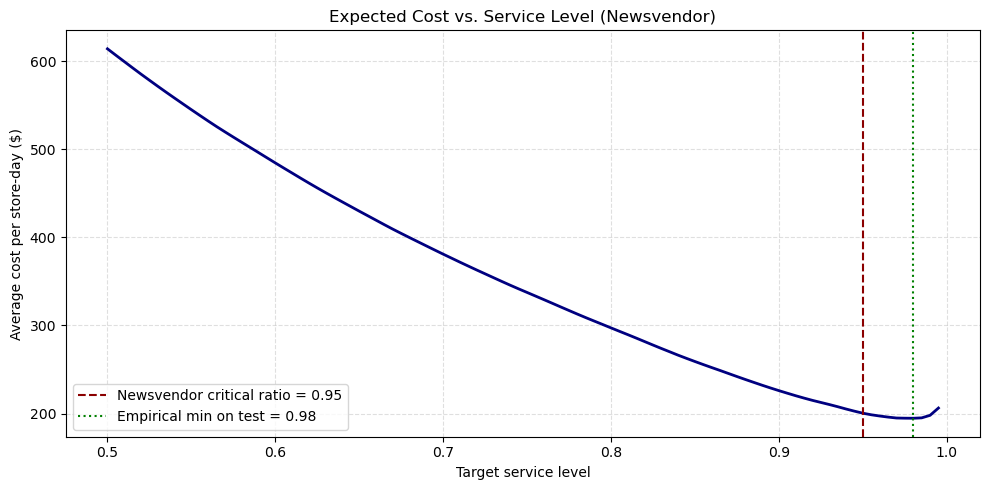

In [402]:
import matplotlib.pyplot as plt
from scipy.stats import norm
 
# ---- Cost assumptions: REPLACE with real figures (per $1 of revenue) ----
COST_UNDER = 0.38   # cost of each $1 of unmet demand (lost margin + goodwill)
COST_OVER  = 0.02   # cost of each $1 of surplus stock (holding / spoilage)
# -------------------------------------------------------------------------
 
CR = COST_UNDER / (COST_UNDER + COST_OVER)      # critical ratio
Z_CR = norm.ppf(CR)
print(f"Critical ratio = {CR:.3f}  ->  z = {Z_CR:.3f}")
 
forecast_model = best_model   # or best_xgb
 
eval_df = pd.DataFrame({
    'Date':     ml_ready_df.loc[test_mask, 'transaction_date'].values,
    'store_id': X_test['store_id'].values,
    'Actual':   np.asarray(y_test),
    'D_hat':    forecast_model.predict(X_test_pruned),
})
eval_df['error'] = eval_df['Actual'] - eval_df['D_hat']
eval_df['sigma_e'] = eval_df.groupby('store_id')['error'].transform(lambda e: e.std(ddof=1))
 
def realized_cost(actual, q, cu=COST_UNDER, co=COST_OVER):
    """Newsvendor loss: cu * shortage + co * leftover."""
    return cu * np.maximum(actual - q, 0) + co * np.maximum(q - actual, 0)
 
# Candidate order quantities
eval_df['Q_point']   = eval_df['D_hat'].clip(lower=0)                              # no safety stock
eval_df['Q_95_rule'] = (eval_df['D_hat'] + norm.ppf(0.95) * eval_df['sigma_e']).clip(lower=0)
eval_df['Q_newsvendor'] = (eval_df['D_hat'] + Z_CR * eval_df['sigma_e']).clip(lower=0)
# Distribution-free version: empirical CR-quantile of each store's errors
q_err = eval_df.groupby('store_id')['error'].transform(lambda e: np.quantile(e, CR))
eval_df['Q_newsvendor_emp'] = (eval_df['D_hat'] + q_err).clip(lower=0)
 
policies = ['Q_point', 'Q_95_rule', 'Q_newsvendor', 'Q_newsvendor_emp']
summary = pd.DataFrame({
    p: {
        'avg_cost_per_day':  realized_cost(eval_df['Actual'], eval_df[p]).mean(),
        'service_level':     (eval_df['Actual'] <= eval_df[p]).mean(),
        'avg_order_level':   eval_df[p].mean(),
    } for p in policies
}).T.round(3)
print(summary)
 
# ---- Cost curve: expected cost across target service levels ----
levels = np.linspace(0.50, 0.995, 100)
curve = [realized_cost(eval_df['Actual'],
                       (eval_df['D_hat'] + norm.ppf(a) * eval_df['sigma_e']).clip(lower=0)).mean()
         for a in levels]
best_level = levels[int(np.argmin(curve))]
 
plt.figure(figsize=(10, 5))
plt.plot(levels, curve, color='navy', linewidth=2)
plt.axvline(CR, color='darkred', linestyle='--', label=f'Newsvendor critical ratio = {CR:.2f}')
plt.axvline(best_level, color='green', linestyle=':', label=f'Empirical min on test = {best_level:.2f}')
plt.xlabel('Target service level'); plt.ylabel('Average cost per store-day ($)')
plt.title('Expected Cost vs. Service Level (Newsvendor)')
plt.legend(); plt.grid(True, linestyle='--', alpha=0.4); plt.tight_layout(); plt.show()


### Final inference : If you only order exactly what your forecasting model predicts, you will run out of stock almost half the time and lose a massive amount of money on missed sales. Adding a standard, textbook safety buffer doesn't fix this either, because retail sales have wild, unpredictable spikes that regular math simply cannot handle. The most profitable solution is to look at your model's actual past mistakes and use that real-world history to calculate your safety net. Since running out of a product is 19 times more expensive than paying to store an extra one on the shelf, the cheapest overall strategy is to buy enough extra inventory to ensure your store stays fully stocked 98% of the time.

### Optimizing solely for statistical accuracy without accounting for asymmetric business costs is financially dangerous, as ordering exact point forecasts yields a disastrous 57.7% service level and 614 in daily penalties. Applying standard normal distribution mathematics (the 95 pervent  rule) also falls short, capping coverage at 92.6% because traditional Z-scores cannot safely buffer heavy-tailed retail demand spikes. The definitive solution is an empirical approach using actual historical error quantiles, which marginally increases average orders but successfully drives the service level up to 94.3% while minimizing daily costs to $189.78. Ultimately, because the penalty for under-stocking is 19 times higher than holding excess inventory, the true financial minimum is achieved by abandoning the theoretical 0.95 critical ratio and targeting an empirical ~98% service level.